## 1. IMPORT REQUIRED LIBRARIES

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
import random
import torch.nn.functional as F

##2. SET UP DEVICE AGNOSTIC CODE

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
print("Using Device:",device)

Using Device: cuda


##3. SET THE SEED

In [5]:
#to maintain data consistency
torch.manual_seed(42)
torch.cuda.manual_seed(42)
random.seed(42)

##4. SETTING UP THE HYPERPARAMETERS

In [6]:
BATCH_SIZE = 128 #the number of images you send at once
PATCH_SIZE = 4 #size of each image block you are sending to the trasnformers
LEARNING_RATE = 3e-4
EPOCHS = 10
NUM_CLASSES = 10 #number of classes in cifar dataset
IMAGE_SIZE = 32
CHANNELS = 3 #RGB
EMBED_DIM = 256 #embedding dimension
MLP_DIM = 512 #dimensions of the feed forward neural network
NUM_HEADS = 8 #mutli head self attention
DEPTH = 6
DROP_RATE = 0.1 #dropout layer rate

##5. DEFINE IMAGE TRANSFORMATIONS


In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.5))
    # normalization helps to converge faster
    # it also makes mathematical computations stable
])

##6. GETTING A DATASET


In [8]:
train_dataset = datasets.CIFAR10(root="data", train=True, download=True, transform=transform)

100%|██████████| 170M/170M [00:04<00:00, 34.6MB/s]


In [9]:
test_dataset = datasets.CIFAR10(root="data", train=False, download=True, transform=transform)

In [10]:
train_dataset

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=0.5, std=0.5)
           )

In [11]:
test_dataset

Dataset CIFAR10
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=0.5, std=0.5)
           )

##7. CONVERTING DATA TO DATALOADERS

Here data is in form of pytorch datasets

DataLoader converts the dataset into batches or mini batches.

This is computatitonally efficient because using batches we can send 128 images(which is the batch size) to the data instead of sending individual images
This also gives more chances to update the gradients each epoch(once per batch). This way more stability

In [12]:
train_loader = DataLoader(dataset=train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True)

test_loader = DataLoader(dataset=test_dataset,
                         batch_size=BATCH_SIZE,
                         shuffle=False)

##8. BUILDING VISION TRANSFORMER MODEL FROM SCRATCH

In [26]:
class PatchEmbedding(nn.Module):
  def __init__(self, image_size, patch_size, in_channels, embed_dim):
    super().__init__()

    self.patch_size = patch_size
    self.proj = nn.Conv2d(in_channels=in_channels, out_channels=embed_dim, kernel_size=patch_size, stride = patch_size)
    num_patches = (image_size // patch_size) ** 2
    self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim)) #learnable vector prepended to the input sentence whose final embedding represents the entire image for classification
    self.pos_embed = nn.Parameter(torch.randn(1, 1 + num_patches, embed_dim))

  def forward(self, x: torch.Tensor):
    B = x.size(0)
    x = self.proj(x) # (B, E, H/P, W/P)
    x = x.flatten(2).transpose(1, 2) # (B, N, E)
    cls_token = self.cls_token.expand(B, -1, -1) # cls token to append to input sentence
    x = torch.cat((cls_token, x), dim=1)
    x = x + self.pos_embed
    return x


In [27]:
class MLP(nn.Module):
  def __init__(self, in_features, hidden_features, drop_rate):
    super().__init__()

    self.fc1 = nn.Linear(in_features=in_features, out_features=hidden_features)
    self.fc2 = nn.Linear(in_features=hidden_features, out_features=in_features)
    self.dropout = nn.Dropout(drop_rate)

  def forward(self, x):
    x = self.dropout(F.gelu(self.fc1(x)))
    x = self.dropout(self.fc2(x))
    return x

In [28]:
class TransformerEncoderLayer(nn.Module):
  def __init__(self, embed_dim, num_heads, drop_rate, mlp_dim):
    super().__init__()

    self.norm1 = nn.LayerNorm(embed_dim)
    self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=drop_rate, batch_first=True)
    self.norm2 = nn.LayerNorm(embed_dim)
    self.mlp = MLP(embed_dim, mlp_dim, drop_rate)

  def forward(self, x):
    x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
    x = x + self.mlp(self.norm2(x))
    return x

In [29]:
class VisionTransformer(nn.Module):
  def __init__(self, img_size, patch_size, in_channels, num_classes, embed_dim, num_heads, depth, mlp_dim, drop_rate):
    super().__init__()

    self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
    self.encoder = nn.Sequential(*[
      TransformerEncoderLayer(embed_dim, num_heads, drop_rate, mlp_dim)
      for _ in range(depth)
    ])
    self.norm = nn.LayerNorm(embed_dim)
    self.head = nn.Linear(embed_dim, num_classes)

  def forward(self, x):
    x = self.patch_embed(x)
    x = self.encoder(x)
    x = self.norm(x)
    cls_token = x[:, 0]
    return self.head(cls_token)

##9. INSTANTIATE MODEL

In [30]:
device

'cuda'

In [31]:
model = VisionTransformer(
    IMAGE_SIZE,
    PATCH_SIZE,
    CHANNELS,
    NUM_CLASSES,
    EMBED_DIM,
    NUM_HEADS,
    DEPTH,
    MLP_DIM,
    DROP_RATE
).to(device)

In [32]:
model

VisionTransformer(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(3, 256, kernel_size=(4, 4), stride=(4, 4))
  )
  (encoder): Sequential(
    (0): TransformerEncoderLayer(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=256, out_features=512, bias=True)
        (fc2): Linear(in_features=512, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerEncoderLayer(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP

##10. LOSS FUNCTION AND OPTIMIZER

In [35]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=LEARNING_RATE)

In [36]:
criterion

CrossEntropyLoss()

In [37]:
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0003
    maximize: False
    weight_decay: 0
)

##11. DEFINING A TRAINING LOOP FUNCTION

In [45]:
def model_train(model, train_loader, criterion, optimizer, device):
  model.train()

  total_loss, correct = 0, 0

  for x, y in train_loader:
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad()
    # forward propagation
    out = model(x)
    # calculate loss
    loss = criterion(out, y)
    # backpropagation
    loss.backward()
    # gradient descent
    optimizer.step()

    total_loss += loss.item() * x.size(0)
    correct += (out.argmax(1) == y).type(torch.float).sum().item()
  # scale the loss (normalize it to make it general accross all batches)
  return total_loss / len(train_loader.dataset), correct / len(train_loader.dataset)

In [46]:
def evaluate(model, test_loader):
  model.eval()
  correct = 0
  with torch.inference_mode():
    for x, y in test_loader:
      x, y = x.to(device), y.to(device)
      out = model(x)
      correct += (out.argmax(1) == y).type(torch.float).sum().item()
  return correct / len(test_loader.dataset)


In [47]:
from tqdm.auto import tqdm

In [49]:
train_accuracies, test_accuracies = [], []
for epoch in tqdm(range(EPOCHS)):
  train_loss, train_acc = model_train(model, train_loader, criterion, optimizer, device)
  test_acc = evaluate(model, test_loader)
  train_accuracies.append(train_acc)
  test_accuracies.append(test_acc)
  print(f"Epoch: {epoch + 1}/{EPOCHS}, Train loss: {train_loss:.4f}, Train loss: {train_loss:.4f}, Train accuracy: {train_acc:.4f}, Test accuracy: {test_acc:.4f}")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1/10, Train loss: 0.5171, Train loss: 0.5171, Train accuracy: 0.8153, Test accuracy: 0.6426
Epoch: 2/10, Train loss: 0.4514, Train loss: 0.4514, Train accuracy: 0.8385, Test accuracy: 0.6358
Epoch: 3/10, Train loss: 0.3918, Train loss: 0.3918, Train accuracy: 0.8598, Test accuracy: 0.6388
Epoch: 4/10, Train loss: 0.3473, Train loss: 0.3473, Train accuracy: 0.8757, Test accuracy: 0.6426
Epoch: 5/10, Train loss: 0.3090, Train loss: 0.3090, Train accuracy: 0.8897, Test accuracy: 0.6418
Epoch: 6/10, Train loss: 0.2758, Train loss: 0.2758, Train accuracy: 0.9011, Test accuracy: 0.6350
Epoch: 7/10, Train loss: 0.2510, Train loss: 0.2510, Train accuracy: 0.9096, Test accuracy: 0.6395
Epoch: 8/10, Train loss: 0.2305, Train loss: 0.2305, Train accuracy: 0.9191, Test accuracy: 0.6310
Epoch: 9/10, Train loss: 0.2070, Train loss: 0.2070, Train accuracy: 0.9259, Test accuracy: 0.6292
Epoch: 10/10, Train loss: 0.1938, Train loss: 0.1938, Train accuracy: 0.9303, Test accuracy: 0.6321


In [51]:
train_accuracies

[0.81532,
 0.83848,
 0.85978,
 0.8757,
 0.8897,
 0.90112,
 0.90962,
 0.9191,
 0.92588,
 0.93026]

In [52]:
test_accuracies

[0.6426, 0.6358, 0.6388, 0.6426, 0.6418, 0.635, 0.6395, 0.631, 0.6292, 0.6321]

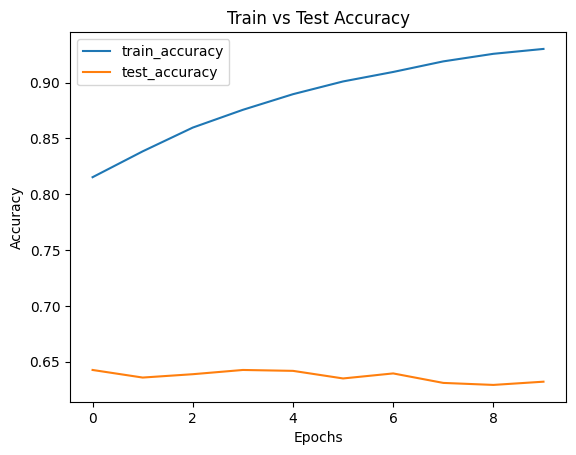

In [53]:
plt.plot(train_accuracies, label="train_accuracy")
plt.plot(test_accuracies, label="test_accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Train vs Test Accuracy")
plt.show()

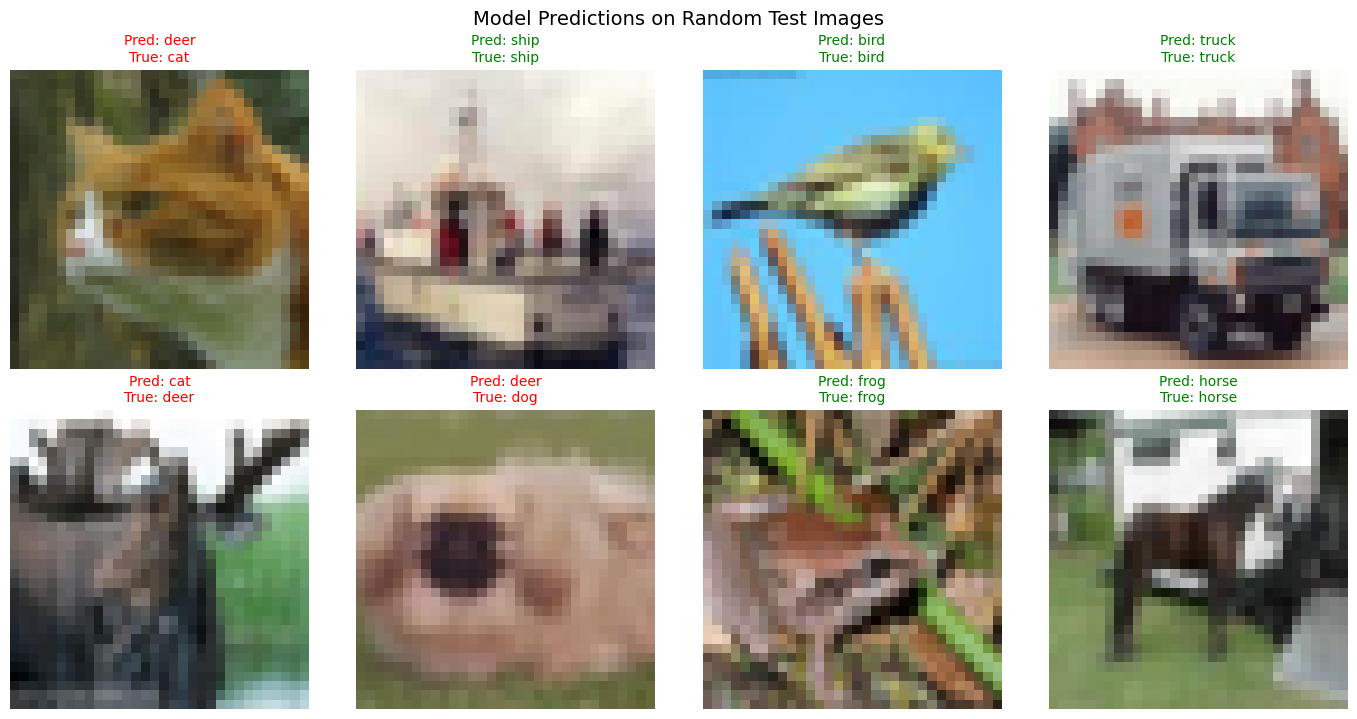

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Define class names
classes = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

# Get one batch from test_loader
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Move to device & predict
images = images.to(device)
model.eval()
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

# Choose how many images to show
n_images = 8

# Randomly select indices
idx = random.sample(range(len(images)), min(n_images, len(images)))

# Create figure
plt.figure(figsize=(14, 7))

for i, sample_idx in enumerate(idx):
    plt.subplot(2, 4, i+1)

    # Unnormalize & show image
    img = images[sample_idx].cpu() / 2 + 0.5
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))

    # Titles
    true_label = classes[labels[sample_idx].item()]
    pred_label = classes[predicted[sample_idx].item()]

    color = 'green' if true_label == pred_label else 'red'
    title = f"Pred: {pred_label}\nTrue: {true_label}"
    plt.title(title, color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.suptitle("Model Predictions on Random Test Images", y=1.02, fontsize=14)
plt.show()